<a href="https://colab.research.google.com/github/vijaydevverse/eda-ml-projects/blob/main/AiDrivenGlobalMarketIntelligenceEdaV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/global_market_ai_dataset.csv")
df

,Record_ID,Date,Market_Type,Market_Name,Country,Asset_Name,Asset_Sector,Opening_Price,Closing_Price,Highest_Price,...,Expected_Return,Confidence_Score,Investment_Recommendation,Suggested_Investment_Level,Market_Trend,Global_Event_Impact,Inflation_Rate,Interest_Rate,Currency_Strength_Index,AI_Model_Version
0,1,2022-12-09,Crypto,LSE,USA,Bitcoin,Crypto,52676.09,43660.12,51867.32,...,-6.99,0.612,Monitor,Medium,Uptrend,Economic Report,8.09,6.00,134.63,v1.0
1,2,2022-12-11,Commodity,Tokyo Exchange,Japan,EUR/USD,Finance,64578.99,44966.81,21289.69,...,2.48,0.311,Invest,Large,Sideways,Market News,10.59,1.73,132.64,v1.0
2,3,2021-10-06,Crypto,Shanghai Exchange,Germany,Ethereum,Technology,1350.39,15228.71,63897.67,...,13.28,0.830,Avoid,Medium,Sideways,NaN,6.91,5.20,88.08,v1.0
3,4,2021-11-12,Forex,Coinbase,Japan,Tesla,Finance,61700.40,69220.31,34334.89,...,-0.46,0.991,Invest,Small,Downtrend,Global Conflict,5.49,2.03,51.24,v1.0
4,5,2023-10-19,Commodity,Tokyo Exchange,USA,EUR/USD,Forex,22195.62,22782.70,8386.38,...,5.48,0.018,Avoid,Large,Sideways,Economic Report,5.77,9.74,132.63,v1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,119996,2020-10-27,Commodity,Tokyo Exchange,Singapore,EUR/USD,Forex,33583.36,47214.89,11090.42,...,5.38,0.688,Monitor,Medium,Downtrend,Economic Report,4.15,3.04,67.33,v1.0
119996,119997,2022-12-17,Forex,NASDAQ,China,Bitcoin,Forex,58539.31,55398.27,31686.43,...,3.98,0.058,Monitor,Medium,Sideways,NaN,8.27,4.39,110.87,v1.0
119997,119998,2023-08-10,Forex,Coinbase,Singapore,Gold,Energy,11144.47,69106.10,43847.35,...,-0.19,0.423,Monitor,Small,Downtrend,Global Conflict,7.59,2.22,72.35,v1.0
119998,119999,2023-11-16,Stock,NASDAQ,UK,Nvidia,Commodities,66638.11,50200.33,17356.34,...,21.66,0.379,Invest,Medium,Sideways,Policy Change,8.45,4.13,134.03,v1.0


In [3]:
df.isnull().sum()

,0
Record_ID,0
Date,0
Market_Type,0
Market_Name,0
Country,0
Asset_Name,0
Asset_Sector,0
Opening_Price,0
Closing_Price,0
Highest_Price,0


In [4]:
df['Global_Event_Impact'].fillna('No_Event', inplace=True)

/tmp/ipykernel_8165/2209335022.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Global_Event_Impact'].fillna('No_Event', inplace=True)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Record_ID                   120000 non-null  int64  
 1   Date                        120000 non-null  object 
 2   Market_Type                 120000 non-null  object 
 3   Market_Name                 120000 non-null  object 
 4   Country                     120000 non-null  object 
 5   Asset_Name                  120000 non-null  object 
 6   Asset_Sector                120000 non-null  object 
 7   Opening_Price               120000 non-null  float64
 8   Closing_Price               120000 non-null  float64
 9   Highest_Price               120000 non-null  float64
 10  Lowest_Price                120000 non-null  float64
 11  Trading_Volume              120000 non-null  int64  
 12  Market_Cap                  120000 non-null  int64  
 13  Price_Change_P

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(120000, 31)

In [8]:
df["Date"]=pd.to_datetime(df["Date"])
df["year"]=df["Date"].dt.year
df["month"]=df["Date"].dt.month
df["day"]=df["Date"].dt.day

df.drop("Date",axis=1,inplace=True)

In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df["Market_Type"]=le.fit_transform(df["Market_Type"])
df["Market_Name"]=le.fit_transform(df["Market_Name"])
df["Country"]=le.fit_transform(df["Country"])
df["Asset_Name"]=le.fit_transform(df["Asset_Name"])
df["Asset_Sector"]=le.fit_transform(df["Asset_Sector"])
df["Technical_Signal"]=le.fit_transform(df["Technical_Signal"])
df["Risk_Level"]=le.fit_transform(df["Risk_Level"])
df["Investment_Recommendation"]=le.fit_transform(df["Investment_Recommendation"])
df["Suggested_Investment_Level"]=le.fit_transform(df["Suggested_Investment_Level"])
df["Market_Trend"]=le.fit_transform(df["Market_Trend"])
df["Global_Event_Impact"]=le.fit_transform(df["Global_Event_Impact"])
df["AI_Model_Version"]=le.fit_transform(df["AI_Model_Version"])

In [10]:
df["Risk_Level"].replace(["Low","Medium","High"],[1,2,3],inplace=True)
df["Suggested_Investment_Level"].replace(["Small","Medium","Large"],[1,2,3],inplace=True)

/tmp/ipykernel_8165/1074315333.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Risk_Level"].replace(["Low","Medium","High"],[1,2,3],inplace=True)
/tmp/ipykernel_8165/1074315333.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [11]:
df.drop(['Record_ID'], axis=1, inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Market_Type                 120000 non-null  int64  
 1   Market_Name                 120000 non-null  int64  
 2   Country                     120000 non-null  int64  
 3   Asset_Name                  120000 non-null  int64  
 4   Asset_Sector                120000 non-null  int64  
 5   Opening_Price               120000 non-null  float64
 6   Closing_Price               120000 non-null  float64
 7   Highest_Price               120000 non-null  float64
 8   Lowest_Price                120000 non-null  float64
 9   Trading_Volume              120000 non-null  int64  
 10  Market_Cap                  120000 non-null  int64  
 11  Price_Change_Percentage     120000 non-null  float64
 12  Volatility_Index            120000 non-null  float64
 13  Liquidity_Scor

In [13]:
df

,Market_Type,Market_Name,Country,Asset_Name,Asset_Sector,Opening_Price,Closing_Price,Highest_Price,Lowest_Price,Trading_Volume,...,Suggested_Investment_Level,Market_Trend,Global_Event_Impact,Inflation_Rate,Interest_Rate,Currency_Strength_Index,AI_Model_Version,year,month,day
0,1,2,6,1,1,52676.09,43660.12,51867.32,53063.77,57609563,...,1,2,0,8.09,6.00,134.63,0,2022,12,9
1,0,6,2,2,3,64578.99,44966.81,21289.69,2683.95,106143268,...,0,1,2,10.59,1.73,132.64,0,2022,12,11
2,1,5,1,3,5,1350.39,15228.71,63897.67,6193.83,196225382,...,1,1,3,6.91,5.20,88.08,0,2021,10,6
3,2,1,2,8,3,61700.40,69220.31,34334.89,20167.17,198022876,...,2,0,1,5.49,2.03,51.24,0,2021,11,12
4,0,6,6,2,4,22195.62,22782.70,8386.38,62952.61,314751103,...,0,1,0,5.77,9.74,132.63,0,2023,10,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,0,6,3,2,4,33583.36,47214.89,11090.42,40416.08,97072403,...,1,0,0,4.15,3.04,67.33,0,2020,10,27
119996,2,3,0,1,4,58539.31,55398.27,31686.43,49992.84,410380935,...,1,1,3,8.27,4.39,110.87,0,2022,12,17
119997,2,1,3,4,2,11144.47,69106.10,43847.35,19086.85,416094304,...,2,0,1,7.59,2.22,72.35,0,2023,8,10
119998,3,3,5,6,0,66638.11,50200.33,17356.34,459.12,497429549,...,1,1,4,8.45,4.13,134.03,0,2023,11,16


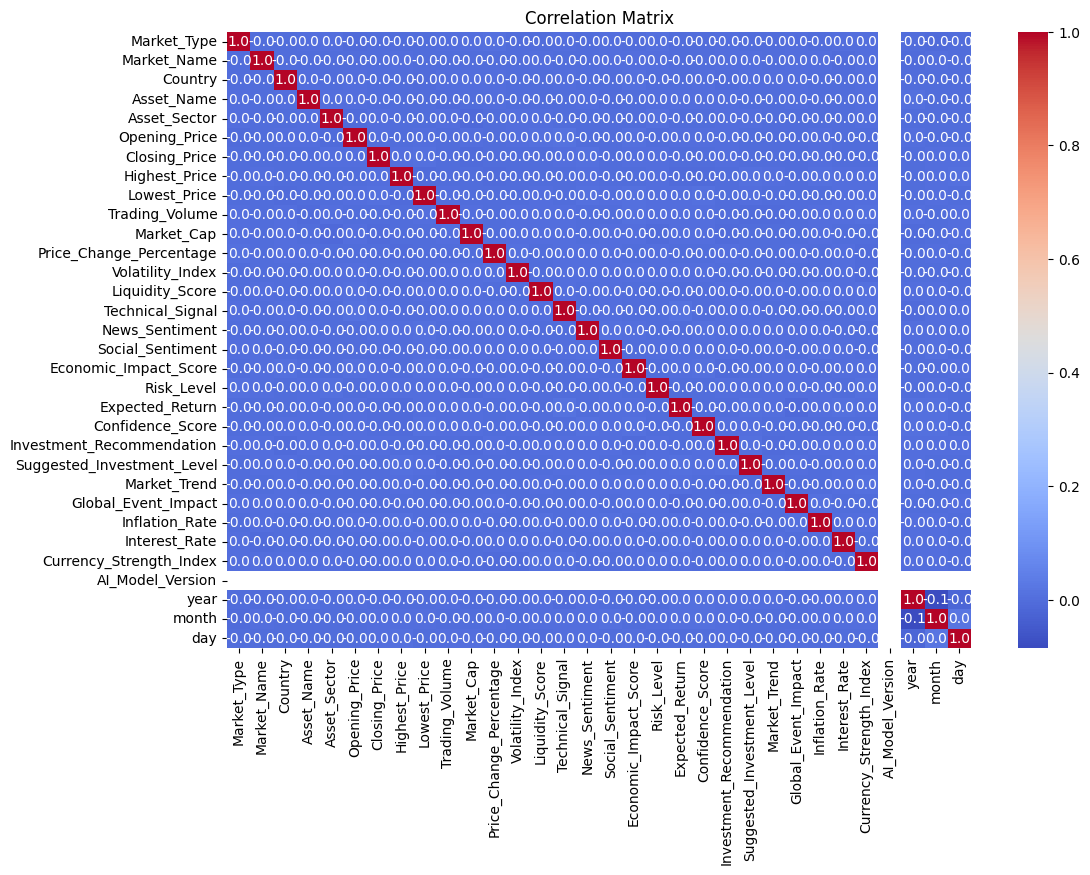

In [14]:
cm=df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(cm,annot=True,fmt=".1f",cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [15]:
X=df.drop("Investment_Recommendation",axis=1)
y=df["Investment_Recommendation"]

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

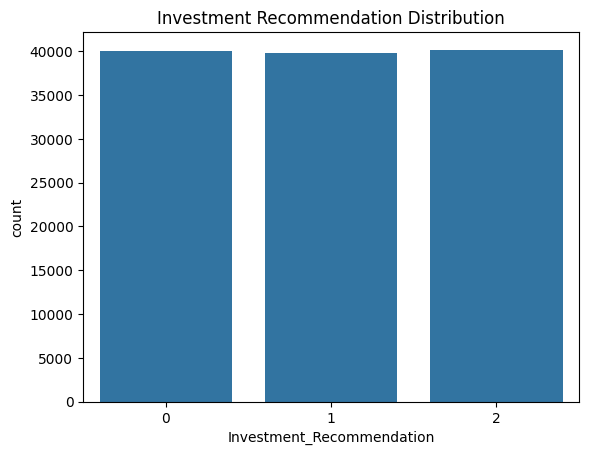

In [17]:
sns.countplot(x="Investment_Recommendation",data=df)
plt.title("Investment Recommendation Distribution")
plt.show()

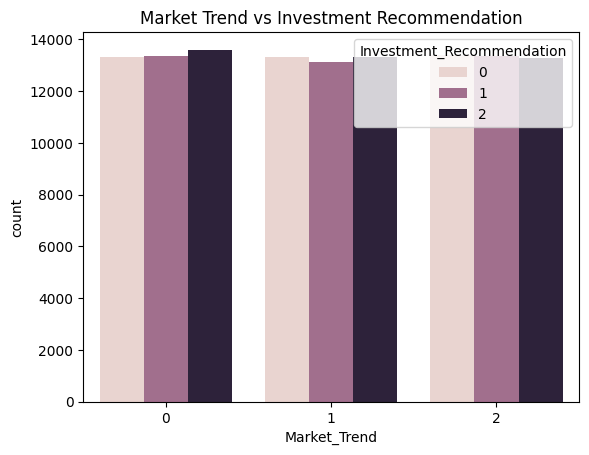

In [18]:
sns.countplot(x="Market_Trend",hue="Investment_Recommendation",data=df)
plt.title("Market Trend vs Investment Recommendation")
plt.show()

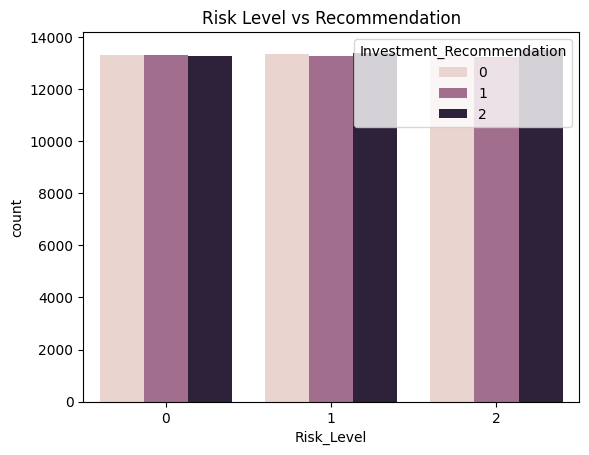

In [19]:
sns.countplot(x="Risk_Level",hue="Investment_Recommendation",data=df)
plt.title("Risk Level vs Recommendation")
plt.show()

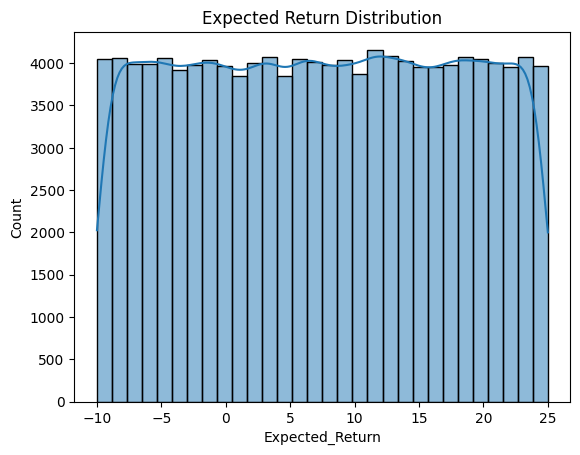

In [20]:
sns.histplot(df["Expected_Return"],bins=30,kde=True)
plt.title("Expected Return Distribution")
plt.show()

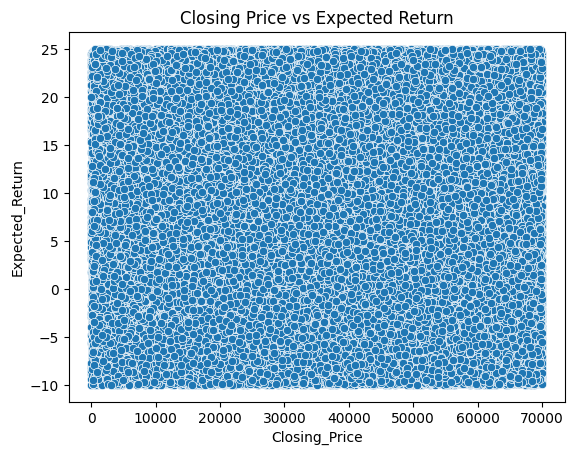

In [21]:
sns.scatterplot(x="Closing_Price",y="Expected_Return",data=df)
plt.title("Closing Price vs Expected Return")
plt.show()

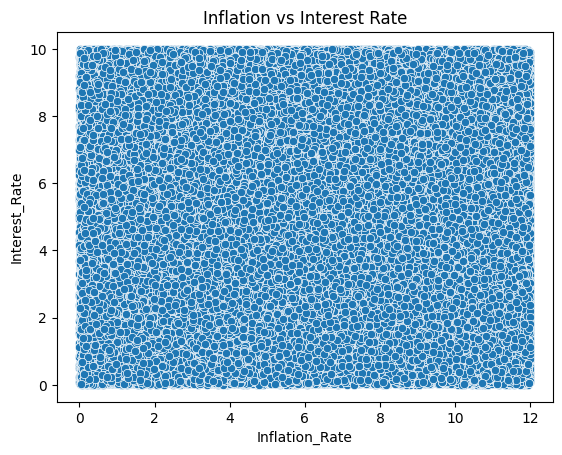

In [22]:
sns.scatterplot(x="Inflation_Rate",y="Interest_Rate",data=df)
plt.title("Inflation vs Interest Rate")
plt.show()

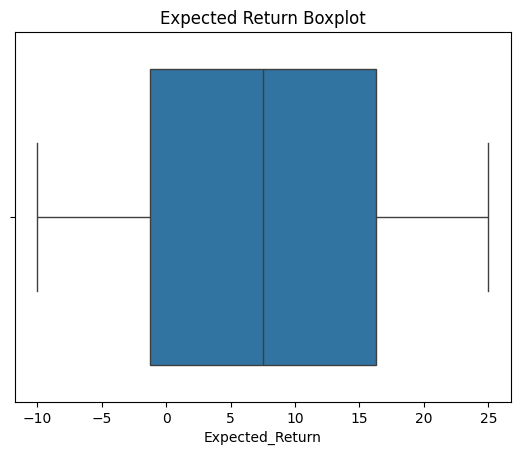

In [23]:
sns.boxplot(x=df["Expected_Return"])
plt.title("Expected Return Boxplot")
plt.show()

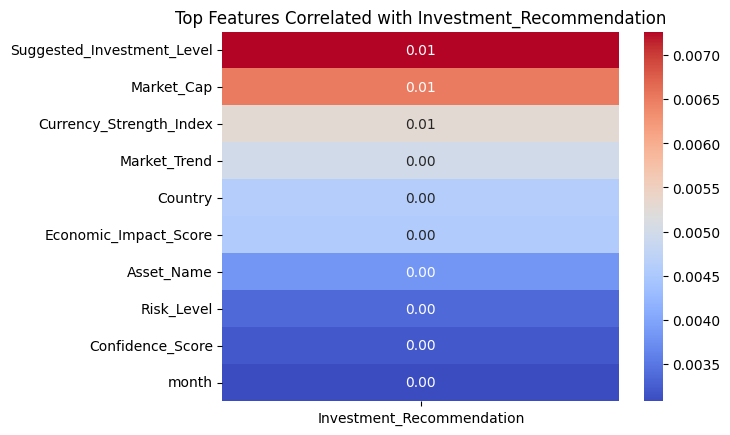

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

target_corr=df.corr(numeric_only=True)["Investment_Recommendation"]
target_corr=target_corr.drop("Investment_Recommendation")
target_corr=target_corr.abs().sort_values(ascending=False)

top_corr=target_corr.head(10)

sns.heatmap(top_corr.to_frame(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Top Features Correlated with Investment_Recommendation")
plt.show()

<Axes: >

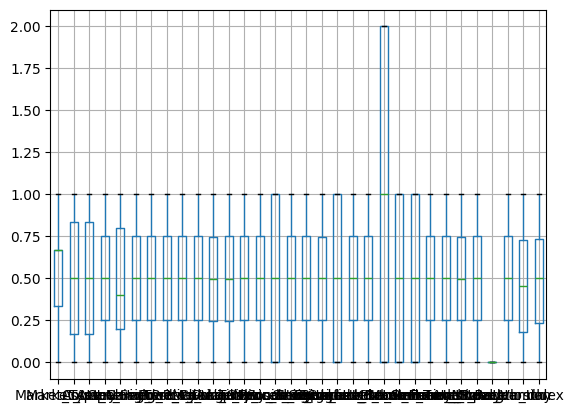

In [32]:
df.boxplot()

In [30]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
    return df

df=remove_outliers_iqr(df,exclude_column="Investment_Recommendation")

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Market_Type                 120000 non-null  float64
 1   Market_Name                 120000 non-null  float64
 2   Country                     120000 non-null  float64
 3   Asset_Name                  120000 non-null  float64
 4   Asset_Sector                120000 non-null  float64
 5   Opening_Price               120000 non-null  float64
 6   Closing_Price               120000 non-null  float64
 7   Highest_Price               120000 non-null  float64
 8   Lowest_Price                120000 non-null  float64
 9   Trading_Volume              120000 non-null  float64
 10  Market_Cap                  120000 non-null  float64
 11  Price_Change_Percentage     120000 non-null  float64
 12  Volatility_Index            120000 non-null  float64
 13  Liquidity_Scor

In [25]:
top_features=top_corr.index
X=df[top_features]

In [31]:
from sklearn.preprocessing import MinMaxScaler

features=df.drop("Investment_Recommendation",axis=1).columns

scaler=MinMaxScaler()
df[features]=scaler.fit_transform(df[features])

In [26]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [27]:
y_pred=model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.3298333333333333
